# Teste 2 — Estudo comparativo de Regressão Linear Múltipla

**Objetivo:** comparar a solução analítica (equação normal), o Gradiente Descendente em Lote e a implementação LinearRegression do scikit-learn na previsão do valor mediano de imóveis.


## 1. Configuração e carregamento dos dados

In [21]:
from pathlib import Path
from time import perf_counter
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

df = pd.read_csv("california_housing.csv")
print(f"Dimensões: {df.shape[0]:,} observações × {df.shape[1]} variáveis")
display(df.head())

Dimensões: 20,640 observações × 9 variáveis


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0000,6.9841,1.0238,322.0000,2.5556,37.8800,-122.2300,4.5260
1,8.3014,21.0000,6.2381,0.9719,"2,401.0000",2.1098,37.8600,-122.2200,3.5850
2,7.2574,52.0000,8.2881,1.0734,496.0000,2.8023,37.8500,-122.2400,3.5210
3,5.6431,52.0000,5.8174,1.0731,558.0000,2.5479,37.8500,-122.2500,3.4130
4,3.8462,52.0000,6.2819,1.0811,565.0000,2.1815,37.8500,-122.2500,3.4220


### Dicionário resumido

- `MedInc`: renda mediana;
- `HouseAge`: idade mediana das casas;
- `AveRooms`, `AveBedrms`: médias de cômodos e quartos por domicílio;
- `Population`: população do distrito;
- `AveOccup`: ocupação média por domicílio;
- `Latitude`, `Longitude`: localização geográfica;
- `MedHouseVal`: valor mediano dos imóveis (centenas de milhares de dólares).

## 2. Análise exploratória

In [22]:
display(df.describe().T)

qualidade = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "percentual_nulos": 100 * df.isna().mean(),
    "duplicados_total": df.duplicated().sum(),
})
display(qualidade)

,count,mean,std,min,25%,50%,75%,max
MedInc,"20,640.0000",3.8707,1.8998,0.4999,2.5634,3.5348,4.7432,15.0001
HouseAge,"20,640.0000",28.6395,12.5856,1.0000,18.0000,29.0000,37.0000,52.0000
AveRooms,"20,640.0000",5.4290,2.4742,0.8462,4.4407,5.2291,6.0524,141.9091
AveBedrms,"20,640.0000",1.0967,0.4739,0.3333,1.0061,1.0488,1.0995,34.0667
Population,"20,640.0000","1,425.4767","1,132.4621",3.0000,787.0000,"1,166.0000","1,725.0000","35,682.0000"
AveOccup,"20,640.0000",3.0707,10.3860,0.6923,2.4297,2.8181,3.2823,"1,243.3333"
Latitude,"20,640.0000",35.6319,2.1360,32.5400,33.9300,34.2600,37.7100,41.9500
Longitude,"20,640.0000",-119.5697,2.0035,-124.3500,-121.8000,-118.4900,-118.0100,-114.3100
MedHouseVal,"20,640.0000",2.0686,1.1540,0.1500,1.1960,1.7970,2.6472,5.0000


,tipo,nulos,percentual_nulos,duplicados_total
MedInc,float64,0,0.0000,0
HouseAge,float64,0,0.0000,0
AveRooms,float64,0,0.0000,0
AveBedrms,float64,0,0.0000,0
Population,float64,0,0.0000,0
AveOccup,float64,0,0.0000,0
Latitude,float64,0,0.0000,0
Longitude,float64,0,0.0000,0
MedHouseVal,float64,0,0.0000,0


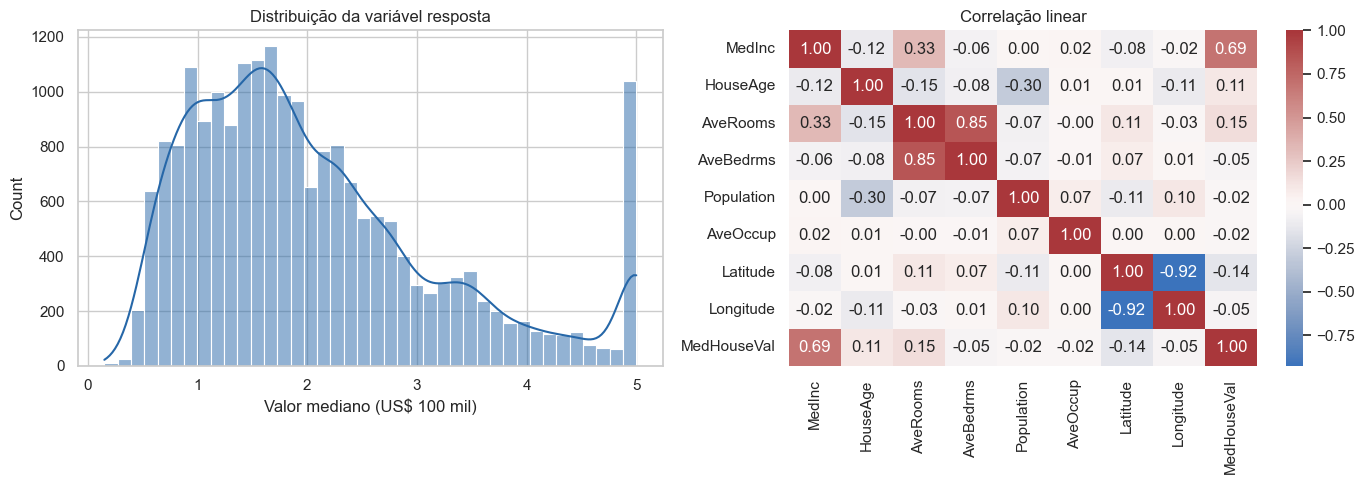

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["MedHouseVal"], bins=40, kde=True, ax=axes[0], color="#2667A8")
axes[0].set(title="Distribuição da variável resposta", xlabel="Valor mediano (US$ 100 mil)")

corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="vlag", center=0, annot=True, fmt=".2f", ax=axes[1])
axes[1].set_title("Correlação linear")
plt.tight_layout()
plt.show()

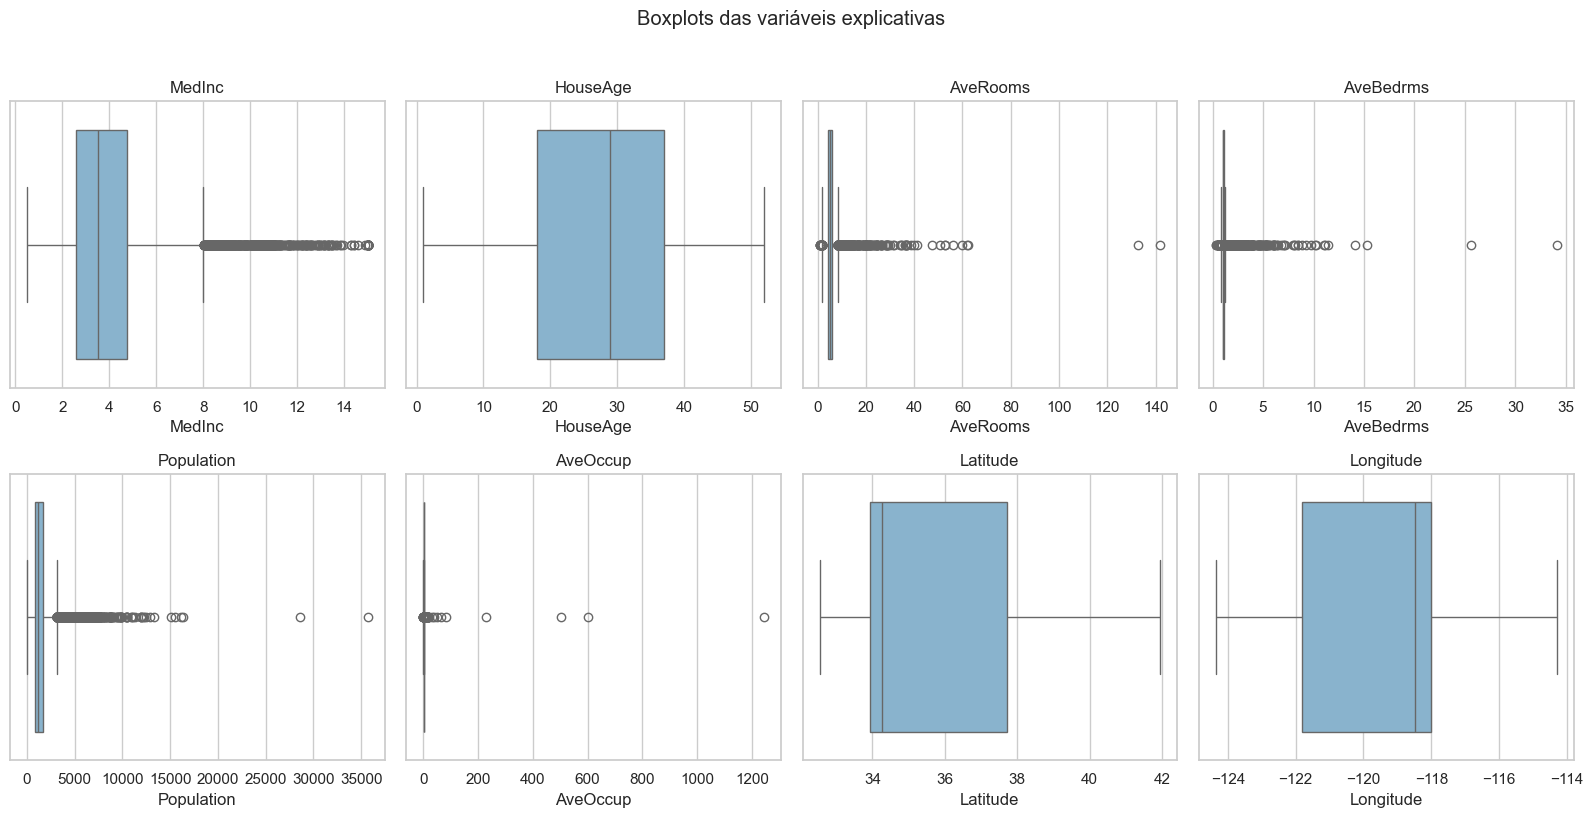

In [24]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for coluna, ax in zip(df.drop(columns="MedHouseVal").columns, axes.flat):
    sns.boxplot(x=df[coluna], ax=ax, color="#7EB6D8")
    ax.set_title(coluna)
plt.suptitle("Boxplots das variáveis explicativas", y=1.02)
plt.tight_layout()
plt.show()

O conjunto não possui valores nulos. Há caudas longas especialmente em AveRooms, AveBedrms, Population e AveOccup. Esses extremos podem dominar a soma de erros quadráticos e tornar o gradiente instável. Por isso, após a divisão treino/teste, será aplicada winsorização pelos limites de 1% e 99% na base de treinamento. Isso reduz a influência de observações extremas sem descartar distritos.

## 3. Separação e pré-processamento

In [25]:
X = df.drop(columns="MedHouseVal")
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

# Limites calculados somente no treino: evita vazamento de informação do teste.
lim_inf = X_train.quantile(0.01)
lim_sup = X_train.quantile(0.99)
X_train_limpo = X_train.clip(lim_inf, lim_sup, axis=1)
X_test_limpo = X_test.clip(lim_inf, lim_sup, axis=1)

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train_limpo)
X_test_std = scaler.transform(X_test_limpo)

print(f"Treino: {X_train_std.shape}; teste: {X_test_std.shape}")
print("Média máxima em módulo após padronização:", np.abs(X_train_std.mean(axis=0)).max())
print("Desvio-padrão (intervalo):", X_train_std.std(axis=0).min(), X_train_std.std(axis=0).max())

Treino: (16512, 8); teste: (4128, 8)
Média máxima em módulo após padronização: 2.192690473634684e-15
Desvio-padrão (intervalo): 0.9999999999999999 1.0


### Padronização

No gradiente descendente, variáveis em escalas muito diferentes produzem componentes do gradiente com magnitudes muito diferentes. A padronização melhora o condicionamento numérico, permite uma única taxa de aprendizagem e acelera a convergência. Também torna os coeficientes comparáveis: cada um passa a expressar a mudança esperada no alvo causada por um desvio-padrão da variável, mantendo as demais constantes.

## 4. Implementação dos três métodos

In [26]:
def adicionar_intercepto(X):
    return np.c_[np.ones(X.shape[0]), X]


def solucao_analitica(X, y):
    """Equação normal com pseudoinversa, estável também sob colinearidade."""
    Xb = adicionar_intercepto(X)
    return np.linalg.pinv(Xb.T @ Xb) @ Xb.T @ np.asarray(y)


def gradiente_descendente_lote(X, y, taxa=0.05, max_iter=10_000, tol=1e-10):
    """Minimiza MSE por Batch Gradient Descent e registra todo o histórico."""
    Xb = adicionar_intercepto(X)
    y_arr = np.asarray(y)
    n = len(y_arr)
    theta = np.zeros(Xb.shape[1])
    historico = []

    for _ in range(max_iter):
        erro = Xb @ theta - y_arr
        mse = np.mean(erro ** 2)
        historico.append(mse)
        gradiente = (2 / n) * (Xb.T @ erro)
        novo_theta = theta - taxa * gradiente
        if np.linalg.norm(novo_theta - theta) < tol:
            theta = novo_theta
            break
        theta = novo_theta

    return theta, np.asarray(historico)


def prever(X, theta):
    return adicionar_intercepto(X) @ theta


def metricas(y_real, y_pred):
    return {
        # Forma compatível com versões antigas e recentes do scikit-learn.
        "RMSE": np.sqrt(mean_squared_error(y_real, y_pred)),
        "R²": r2_score(y_real, y_pred),
    }

In [27]:
resultados = []
coeficientes = {}

# Método 1 — solução fechada
inicio = perf_counter()
theta_normal = solucao_analitica(X_train_std, y_train)
tempo_normal = perf_counter() - inicio
pred_normal = prever(X_test_std, theta_normal)
resultados.append({"Método": "Equação normal", **metricas(y_test, pred_normal),
                   "Tempo (s)": tempo_normal, "Iterações": 1})
coeficientes["Equação normal"] = theta_normal

# Método 2 — Batch Gradient Descent
inicio = perf_counter()
theta_gd, historico = gradiente_descendente_lote(X_train_std, y_train)
tempo_gd = perf_counter() - inicio
pred_gd = prever(X_test_std, theta_gd)
resultados.append({"Método": "Gradiente descendente", **metricas(y_test, pred_gd),
                   "Tempo (s)": tempo_gd, "Iterações": len(historico)})
coeficientes["Gradiente descendente"] = theta_gd

# Método 3 — biblioteca estatística/ML (decomposição numérica do scikit-learn)
inicio = perf_counter()
modelo_sklearn = LinearRegression().fit(X_train_std, y_train)
tempo_sklearn = perf_counter() - inicio
pred_sklearn = modelo_sklearn.predict(X_test_std)
theta_sklearn = np.r_[modelo_sklearn.intercept_, modelo_sklearn.coef_]
resultados.append({"Método": "scikit-learn", **metricas(y_test, pred_sklearn),
                   "Tempo (s)": tempo_sklearn, "Iterações": np.nan})
coeficientes["scikit-learn"] = theta_sklearn

tabela_resultados = pd.DataFrame(resultados).set_index("Método")
display(tabela_resultados)

,RMSE,R²,Tempo (s),Iterações
Método,,,,
Equação normal,0.6702,0.6572,0.0064,1.0000
Gradiente descendente,0.6702,0.6572,0.5323,"3,702.0000"
scikit-learn,0.6702,0.6572,0.0022,NaN


## 5. Convergência e comparação

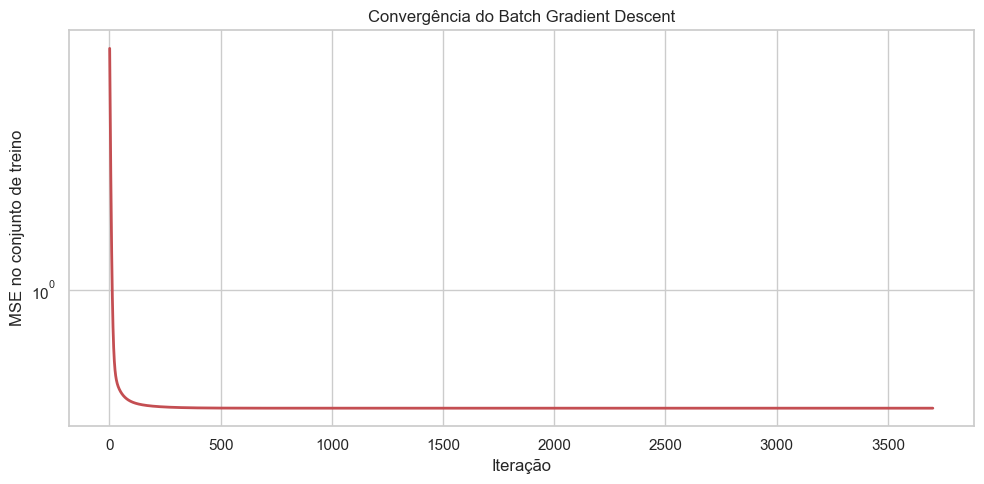

MSE inicial: 5.62974232
MSE final:   0.42834081
Redução:     92.3915%


In [28]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.arange(1, len(historico) + 1), historico, color="#C44E52", lw=2)
ax.set(title="Convergência do Batch Gradient Descent",
       xlabel="Iteração", ylabel="MSE no conjunto de treino")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

print(f"MSE inicial: {historico[0]:.8f}")
print(f"MSE final:   {historico[-1]:.8f}")
print(f"Redução:     {100 * (1 - historico[-1] / historico[0]):.4f}%")

In [29]:
nomes = ["Intercepto"] + X.columns.tolist()
tabela_coef = pd.DataFrame(coeficientes, index=nomes)
tabela_coef["amplitude (máx.-mín.)"] = tabela_coef.max(axis=1) - tabela_coef.min(axis=1)
display(tabela_coef)

maior_diferenca = tabela_coef["amplitude (máx.-mín.)"].max()
print(f"Maior diferença absoluta entre coeficientes: {maior_diferenca:.3e}")

,Equação normal,Gradiente descendente,scikit-learn,amplitude (máx.-mín.)
Intercepto,2.0719,2.0719,2.0719,0.0000
MedInc,0.8744,0.8744,0.8744,0.0000
HouseAge,0.1557,0.1557,0.1557,0.0000
AveRooms,-0.1898,-0.1898,-0.1898,0.0000
AveBedrms,0.1826,0.1826,0.1826,0.0000
Population,0.0496,0.0496,0.0496,0.0000
AveOccup,-0.2586,-0.2586,-0.2586,0.0000
Latitude,-0.8837,-0.8837,-0.8837,0.0000
Longitude,-0.8187,-0.8187,-0.8187,0.0000


Maior diferença absoluta entre coeficientes: 1.438e-08


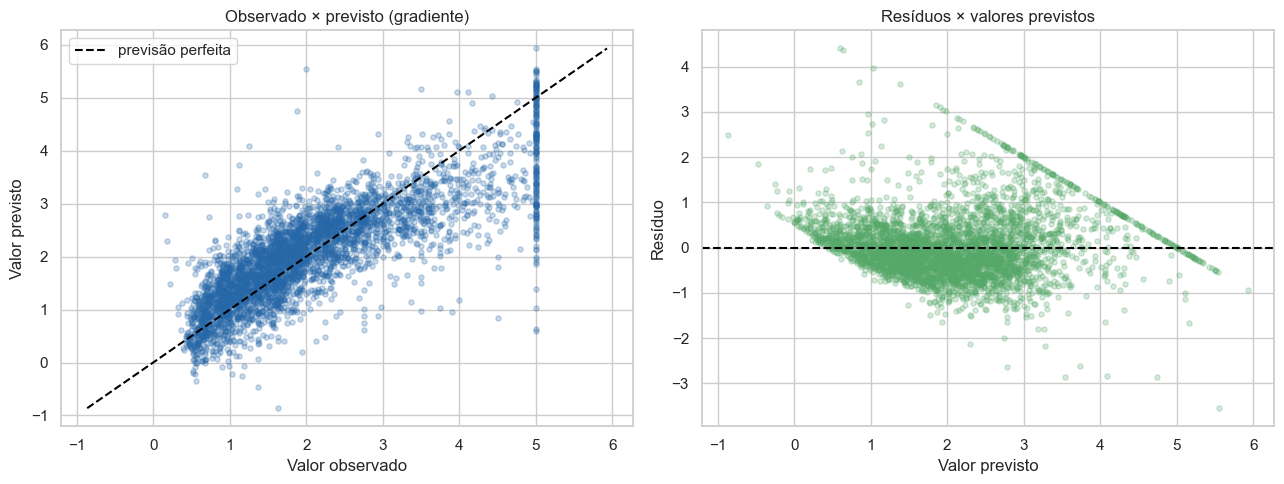

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, pred_gd, alpha=.25, s=14, color="#2667A8")
limites = [min(y_test.min(), pred_gd.min()), max(y_test.max(), pred_gd.max())]
axes[0].plot(limites, limites, "--", color="black", label="previsão perfeita")
axes[0].set(xlabel="Valor observado", ylabel="Valor previsto",
            title="Observado × previsto (gradiente)")
axes[0].legend()

residuos = y_test.to_numpy() - pred_gd
axes[1].scatter(pred_gd, residuos, alpha=.25, s=14, color="#55A868")
axes[1].axhline(0, ls="--", color="black")
axes[1].set(xlabel="Valor previsto", ylabel="Resíduo",
            title="Resíduos × valores previstos")
plt.tight_layout()
plt.show()

## 6. Discussão dos resultados

In [34]:
rmse = tabela_resultados.loc["Gradiente descendente", "RMSE"]
r2 = tabela_resultados.loc["Gradiente descendente", "R²"]
iters = int(tabela_resultados.loc["Gradiente descendente", "Iterações"])
mais_rapido = tabela_resultados["Tempo (s)"].idxmin()

display(Markdown(f"""
Os três métodos chegam, dentro da precisão numérica, aos mesmos coeficientes e à mesma capacidade preditiva. No teste, o modelo apresenta **RMSE = {rmse:.4f}** (cerca de **US$ {rmse * 100_000:,.0f}**) e **R² = {r2:.4f}**. Assim, o modelo linear explica aproximadamente **{100*r2:.1f}%** da variabilidade do valor mediano dos imóveis nos dados não usados no ajuste.

O gradiente convergiu em **{iters:,} iterações**. Nesta execução, **{mais_rapido}** apresentou o menor tempo medido.

Os gráficos de resíduos indicam limitações da hipótese estritamente linear, além do teto visível da variável resposta próximo de 5 (aproximadamente US$ 500 mil). 
"""))


Os três métodos chegam, dentro da precisão numérica, aos mesmos coeficientes e à mesma capacidade preditiva. No teste, o modelo apresenta **RMSE = 0.6702** (cerca de **US$ 67,025**) e **R² = 0.6572**. Assim, o modelo linear explica aproximadamente **65.7%** da variabilidade do valor mediano dos imóveis nos dados não usados no ajuste.

O gradiente convergiu em **3,702 iterações**. Nesta execução, **scikit-learn** apresentou o menor tempo medido.

Os gráficos de resíduos indicam limitações da hipótese estritamente linear, além do teto visível da variável resposta próximo de 5 (aproximadamente US$ 500 mil). 


### Quando a solução fechada deixa de ser viável?

Com $n$ observações e $p$ variáveis, formar $X^TX$ custa aproximadamente $O(np^2)$ e inverter/decompor a matriz custa $O(p^3)$, além de exigir memória da ordem de $O(p^2)$. Portanto, a solução fechada perde viabilidade quando há dezenas ou centenas de milhares de atributos, como em texto, genômica ou grandes matrizes esparsas. Ela também pode sofrer instabilidade numérica diante de forte multicolinearidade — neste trabalho foi usada a pseudoinversa para reduzir esse problema.

O gradiente descendente não precisa formar nem inverter $X^TX$: cada época custa aproximadamente $O(np)$, pode trabalhar em lotes e admite processamento distribuído ou incremental. Em contrapartida, exige escolher taxa de aprendizagem, critério de parada e número de iterações; sem padronização pode convergir lentamente ou divergir. Para este conjunto pequeno, a solução analítica e a biblioteca são mais simples e rápidas; em grande escala, métodos iterativos tornam-se a escolha natural.

## 7. Conclusão

A implementação confirmou a equivalência prática entre a equação normal, o Batch Gradient Descent convergido e o estimador do scikit-learn. O pré-processamento aprendido exclusivamente no treino evitou vazamento de dados, enquanto a padronização tornou a otimização iterativa estável. Para o problema atual, a solução direta é conveniente; a principal vantagem do gradiente é sua capacidade de escalar para um número de atributos ou observações em que operações matriciais quadráticas/cúbicas deixam de ser aceitáveis.